In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
import matplotlib as mpl

g = 9.805
mpl.rc('font',family='Times New Roman')

In [2]:
def Gamma(D1):
    s = 0
    ss = 0
    for i in range(len(D1)):
        s = D1[i]*m[i] + s
        ss = D1[i]**2*m[i] + ss
    return s/ss, s**2/ss

In [3]:
m = [0, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0,
     0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0,
     0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.37, 0.0] 

In [4]:
np.sum(m)

22.570000000000004

In [5]:
im = 9

In [6]:
model = 'M62_biron'

In [7]:
dispX = np.loadtxt(model+"_DispX.txt")
dispY = np.loadtxt(model+"_DispY.txt")

In [8]:
Dxm = np.zeros(10)
Dym = np.zeros(10)

for i in range(len(Dxm)):
    dx = dispX[:,i]
    dx = dx[dx != 0]
    Dxm[i] = np.median(dx)
    
    dy = dy = dispY[:,i]
    dy = dy[dy != 0]
    Dym[i] = np.median(dy)

In [9]:
data = np.load("M62_peak_displacements.npy", allow_pickle=True).item()

dispXs = data["dispXs"]
dispYs = data["dispYs"]

In [10]:
DxmS = np.zeros(10)
DymS = np.zeros(10)

for i in range(10):
    DxmS[i] = np.median(dispXs[:,i])
    DymS[i] = np.median(dispYs[:,i])


Text(0, 0.5, 'Peak Suspended Piping Displacement')

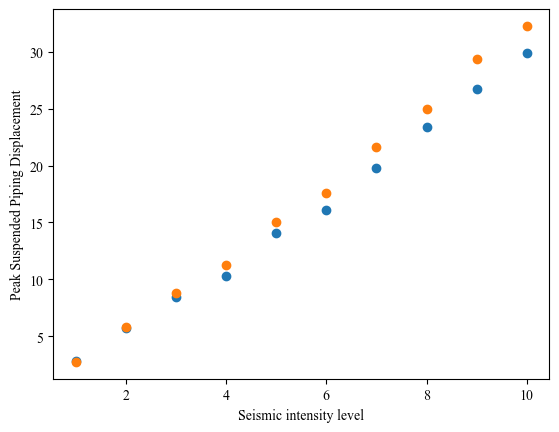

In [11]:
im = [1,2,3,4,5,6,7,8,9,10]
plt.scatter(im,Dxm)
plt.scatter(im,DxmS*0.76*1.57)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'Peak Suspended Piping Displacement')

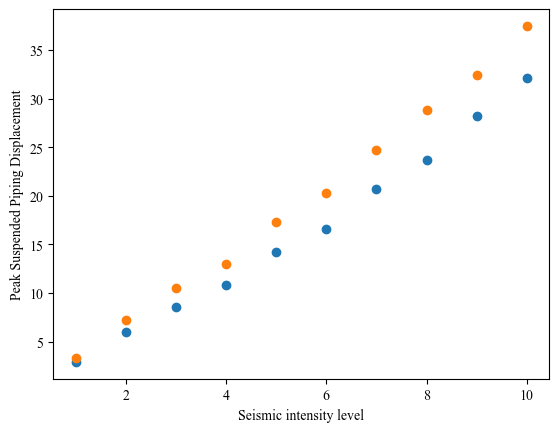

In [12]:

#plt.scatter(im,Dxm)
plt.scatter(im,Dym)
plt.scatter(im,DymS*0.81*1.44)
plt.xlabel('Seismic intensity level')
plt.ylabel('Peak Suspended Piping Displacement')

Text(0, 0.5, 'MRE')

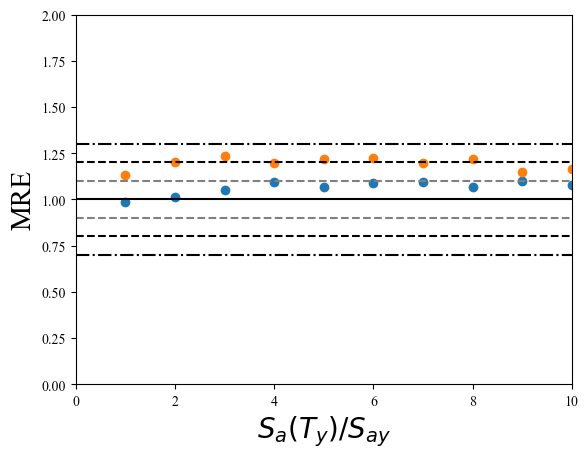

In [13]:
plt.scatter(im,DxmS*0.76*1.57/Dxm)
plt.scatter(im,DymS*0.81*1.44/Dym)

plt.plot((0,10),(1.1,1.1),color='grey',ls='--')
plt.plot((0,10),(0.9,0.9),color='grey',ls='--')

plt.plot((0,10),(1.2,1.2),color='k',ls='--')
plt.plot((0,10),(0.8,0.8),color='k',ls='--')

plt.plot((0,10),(1.3,1.3),color='k',ls='-.')
plt.plot((0,10),(0.7,0.7),color='k',ls='-.')

plt.plot((0,10),(1,1),color='k')
plt.ylim(0,2)
plt.xlim(0,10)
plt.xlabel(r'$S_{a}(T_y)/S_{ay}$',fontsize=20)
plt.ylabel(r'MRE',fontsize=20)

In [14]:
DispShapeX = np.load(model+"DispShapeX.npy")
DispShapeY = np.load(model+"DispShapeY.npy")

In [15]:
def DispShapeStat(DispShapeX,DispShapeY):
    tol = 0
    mask_rowsX = np.any(DispShapeX > tol, axis=(1))
    mask_rowsY = np.any(DispShapeY > tol, axis=(1))
    
    DispShapeX_no_zero = DispShapeX[mask_rowsX, :]
    DispShapeY_no_zero = DispShapeY[mask_rowsY, :]
    
    DSXm = DispShapeX_no_zero.mean(axis=0)
    DSYm = DispShapeY_no_zero.mean(axis=0)
    
    DSXs = DispShapeX_no_zero.std(axis=0)
    DSYs = DispShapeY_no_zero.std(axis=0)

    return DSXm,DSYm,DSXs,DSYs

In [16]:
DSXm = np.zeros((66,10))
DSYm = np.zeros((66,10))

DSXs = np.zeros((66,10))
DSYs = np.zeros((66,10))

for i in range(10):
    DSXm[:,i],DSYm[:,i],DSXs[:,i],DSYs[:,i] = DispShapeStat(DispShapeX[:,:,i],DispShapeY[:,:,i])

In [17]:

POy = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M62y.txt')
POx = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover2D/pushover_results_M62x.txt')

In [18]:
Vbx_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM62x_SDOF/VbaseC.out')
Dx_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM62x_SDOF/DispC.out')

In [19]:
Vby_SDOF = -1*np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM62y_SDOF/VbaseC.out')
Dy_SDOF = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover_SDOF/ResultsM62y_SDOF/DispC.out')

In [20]:
Fx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM62_biron/ReactionsX.out')

Vbx_3D = np.zeros(len(Fx_3D[:,0]))
for i in range(len(Vbx_3D)):
    Vbx_3D[i] = -1*np.sum(Fx_3D[i,1:])

Dx_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM62_biron/PipeNodeDispX.out')

Dx3D_eq = np.zeros(len(Dx_3D[:,0]))
for i in range(len(Dx3D_eq)):
    Dx3D_eq[i] = np.sum(Dx_3D[i,1:]**2)/np.sum(Dx_3D[i,1:])

In [21]:
Fy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM62_biron/ReactionsY.out')

Vby_3D = np.zeros(len(Fy_3D[:,0]))
for i in range(len(Vby_3D)):
    Vby_3D[i] = -1*np.sum(Fy_3D[i,1:])

Dy_3D = np.loadtxt('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Archetypes/Pushover/ResultsM62_biron/PipeNodeDispY.out')

Dy3D_eq = np.zeros(len(Dy_3D[:,0]))
for i in range(len(Dy3D_eq)):
    Dy3D_eq[i] = np.sum(Dy_3D[i,1:]**2)/np.sum(Dy_3D[i,1:])

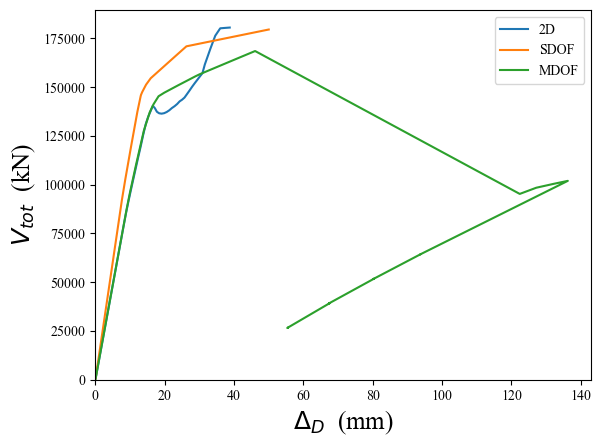

In [23]:
plt.plot(POx[:,5],POx[:,3]*2,label='2D') 
plt.plot(Dx_SDOF,Vbx_SDOF,label='SDOF')
plt.plot(Dx3D_eq,Vbx_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

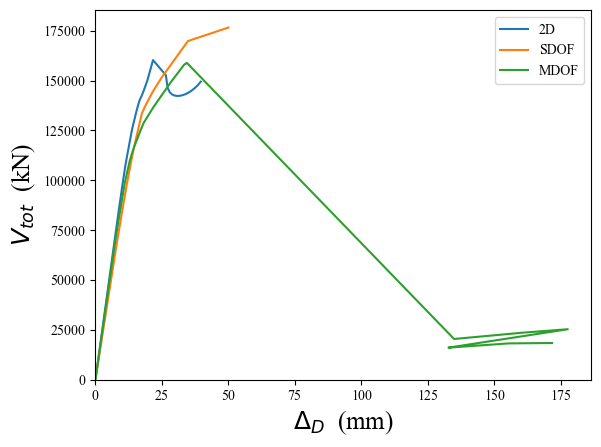

In [24]:
plt.plot(POy[:,5],POy[:,3],label='2D')
plt.plot(Dy_SDOF,Vby_SDOF,label='SDOF')
plt.plot(Dy3D_eq,Vby_3D,label='MDOF')

plt.xlabel(r'$\Delta_{D}$  (mm)',fontsize=18)
plt.ylabel(r'$V_{tot}$  (kN)',fontsize=18)
plt.xlim(0)
plt.ylim(0)
plt.legend()

In [25]:
#Dstaticx = POx[:,6:24]
Dstaticx = np.flip(POx[10,6:24])

In [26]:
Dstaticy = POy[:,6:35]


In [30]:
im = 8

In [31]:
x0m = np.zeros(30)
y0m = np.zeros(30)


x0m[0] = 0.0
x0m[1] = 1.0
x0m[2] = 4.0
x0m[3] = 7.0
x0m[4] = 10.0
x0m[5] = 13.0
x0m[6] = 16.0
x0m[7] = 19.0
x0m[8] = 22.0
x0m[9] = 25.0
x0m[10] = 28.0
x0m[11] = 31.0
x0m[12] = 32.0
x0m[13] = 34.0
x0m[14] = 37.0
x0m[15] = 40.0
x0m[16] = 43.0
x0m[17] = 46.0
x0m[18] = 49.0
x0m[19] = 52.0
x0m[20] = 55.0
x0m[21] = 58.0
x0m[22] = 61.0
x0m[23] = 64.0
x0m[24] = 67.0
x0m[25] = 70.0
x0m[26] = 73.0
x0m[27] = 76.0
x0m[28] = 79.0
x0m[29] = 82.0


In [32]:
x0b1 = 82*np.ones(19)
y0b1 = np.zeros(19)

y0b1[1] = 1.0
for i in range(2,19):
    y0b1[i] = y0b1[1]+3*(i-1)

x0b2 = 32*np.ones(19)
y0b2 = np.zeros(19)

y0b2[1] = 1.0
for i in range(2,19):
    y0b2[i] = y0b2[1]+3*(i-1)

In [33]:
DSXML = DSXm[:30,im]
DSXBL1 = DSXm[30:48,im]
DSXBL2 = DSXm[48:66,im]

DSXMLs = DSXs[:30,im]
DSXBL1s = DSXs[30:48,im]
DSXBL2s = DSXs[48:66,im]

DSXBL1 = np.insert(DSXBL1,0,DSXm[19,im])
DSXBL2 = np.insert(DSXBL2,0,DSXm[29,im])

DSXBL1s = np.insert(DSXBL1s,0,DSXs[19,im])
DSXBL2s = np.insert(DSXBL2s,0,DSXs[29,im])

DSYML = DSYm[:30,im]
DSYBL1 = DSYm[30:48,im]
DSYBL2 = DSYm[48:66,im]

DSYMLs = DSYs[:30,im]
DSYBL1s = DSYs[30:48,im]
DSYBL2s = DSYs[48:66,im]

DSYBL1 = np.insert(DSYBL1,0,DSYm[19,im])
DSYBL2 = np.insert(DSYBL2,0,DSYm[29,im])

DSYBL1s = np.insert(DSYBL1s,0,DSYs[19,im])
DSYBL2s = np.insert(DSYBL2s,0,DSYs[29,im])

In [34]:
dsdxm = np.ones(len(x0m))
dsdxb = np.ones(len(x0b1))

dsdxb = np.multiply(dsdxb,np.append(0,Dstaticx))

In [35]:
DNLTHx = np.concatenate([DSXML,DSXBL1,DSXBL2])
Dstatx = np.concatenate([DSXML,np.append(Dstaticx[0],Dstaticx),np.append(Dstaticx[0],Dstaticx)])

In [36]:
np.mean(abs(DNLTHx-Dstatx)/DNLTHx)

0.03918911213284049

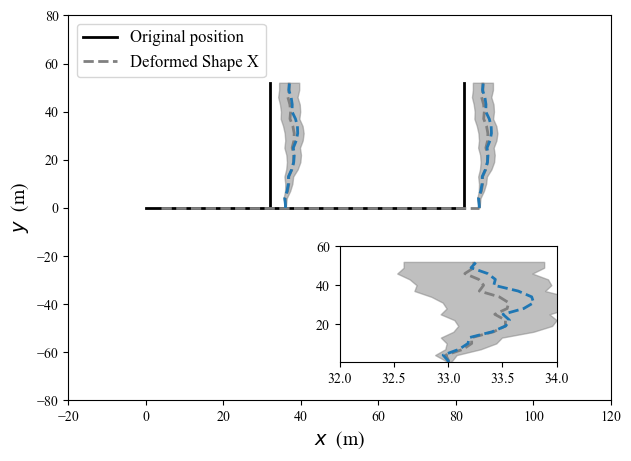

In [37]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))

ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)

ampx = 4
ax.plot(x0m+ampx*DSXML,y0m, color='grey',lw=2, ls='--',label='Deformed Shape X')
ax.plot(x0b1+ampx*DSXBL1,y0b1, color='grey',lw=2, ls='--')
ax.plot(x0b2+ampx*DSXBL2,y0b2, color='grey',lw=2, ls='--')

ax.plot(x0b1+ampx*np.append(Dstaticx[0],Dstaticx),y0b1, color='C0',lw=2, ls='--')
ax.plot(x0b2+ampx*np.append(Dstaticx[0],Dstaticx),y0b2, color='C0',lw=2, ls='--')
ax.fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)
ax.fill_betweenx(y0b1,x0b1+ampx*(DSXBL2+2*DSXBL2s),x0b1+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)


axins1 = ax.inset_axes([0.5, 0.1, 0.4, 0.3],xlim=(32,34), ylim=(0.5, 60))
axins1.plot(x0b2+DSXBL1,y0b2, color='grey',lw=2, ls='--')
axins1.plot(x0b2+np.append(Dstaticx[0],Dstaticx),y0b2, color='C0',lw=2, ls='--')
axins1.fill_betweenx(y0b2,x0b2+(DSXBL2+2*DSXBL2s),x0b2+(DSXBL2-2*DSXBL2s),color='grey',alpha=0.5)
#axins1.fill_between(x0b1,y0b1+(DSYb1m[:,im]+2*DSYs[:,im]),y0+(DSYm[:,im]-2*DSYs[:,im]),color='grey',alpha=0.5)
#axins1.plot(x0,y0+dsdy, color='C0',ls='--',label='Displaced shape Static')

ax.set_xlim(-20, 120)
ax.set_ylim(-80,80)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

ax.legend(fontsize=12,loc=2)

In [38]:
Gx_NLTH, mx_NLTH = Gamma(DSXm[:,5])
Gx_NLTH

0.832711603637869

In [39]:
mx_NLTH/np.sum(m)

0.9703463809284052

In [40]:
mx_NLTH

21.90071781755411

In [41]:
np.sum(m)

22.570000000000004

In [42]:
Gx_static = POx[10,1]
Gx_static

0.782

In [43]:
mx_static = POx[10,2]
mx_static

22.037

In [44]:
POx[10,4]*np.sum(m)

21.554350000000003

In [45]:
abs(Gx_static-Gx_NLTH)/Gx_NLTH

0.060899359894019824

In [46]:
abs(mx_static-mx_NLTH)/mx_NLTH

0.00622272674262095

In [47]:
Dstaticx

array([1.   , 0.953, 1.1  , 1.182, 1.193, 1.404, 1.53 , 1.564, 1.505,
       1.696, 1.787, 1.769, 1.644, 1.42 , 1.434, 1.363, 1.21 , 1.26 ])

In [48]:
np.append(Dstaticy[10,0],Dstaticy[10,:])

array([0.487, 0.487, 0.669, 0.773, 0.787, 1.064, 1.217, 1.226, 1.092,
       1.324, 1.401, 1.313, 1.302, 1.315, 1.251, 1.035, 1.161, 1.147,
       1.511, 1.691, 1.665, 1.436, 1.681, 1.721, 1.551, 1.192, 1.226,
       1.112, 0.862, 1.   ])

In [49]:
dsdy = np.ones(len(y0m))
print(y0m)

dsdy = np.multiply(dsdy,np.append(Dstaticy[10,0],Dstaticy[10,:]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]


In [50]:
DNLTHy=np.concatenate([DSYML,DSYBL1,DSYBL2])
Dstaty = np.concatenate([dsdy,dsdy[-1]*np.ones(len(y0b1)),dsdy[12]*np.ones(len(y0b2))])

In [51]:
DNLTHy

array([0.66754074, 0.6675716 , 0.79177155, 0.86399176, 0.87170765,
       1.01557545, 1.08779988, 1.08037135, 0.99725401, 1.07781477,
       1.08837901, 1.01818414, 1.00238014, 0.96604954, 1.09638877,
       1.15526529, 1.13701399, 1.3105616 , 1.39997796, 1.39741414,
       1.30273935, 1.39758628, 1.39671319, 1.30035805, 1.12266012,
       1.13144258, 1.06194201, 0.91882825, 0.94496665, 0.8785375 ,
       1.39741414, 0.87850153, 0.87878312, 0.87891167, 0.87888555,
       0.87870539, 0.87891588, 0.87897248, 0.87887597, 0.87862626,
       0.87876713, 0.87875546, 0.87858964, 0.87827067, 0.87834169,
       0.87825887, 0.87802173, 0.87763014, 0.87763014, 0.8785375 ,
       1.00228818, 1.00253958, 1.00259282, 1.0024479 , 1.002105  ,
       1.00228944, 1.00227534, 1.00206413, 1.00165515, 1.00177379,
       1.00169571, 1.00142006, 1.00094809, 1.00100412, 1.00086491,
       1.00052977, 1.        , 1.        ])

In [52]:
Dstaty

array([0.487, 0.487, 0.669, 0.773, 0.787, 1.064, 1.217, 1.226, 1.092,
       1.324, 1.401, 1.313, 1.302, 1.315, 1.251, 1.035, 1.161, 1.147,
       1.511, 1.691, 1.665, 1.436, 1.681, 1.721, 1.551, 1.192, 1.226,
       1.112, 0.862, 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.302, 1.302, 1.302, 1.302, 1.302,
       1.302, 1.302, 1.302, 1.302, 1.302, 1.302, 1.302, 1.302, 1.302,
       1.302, 1.302, 1.302, 1.302, 1.302])

In [53]:
np.mean(abs(DNLTHy-Dstaty)/DNLTHy)

0.20519393107376033

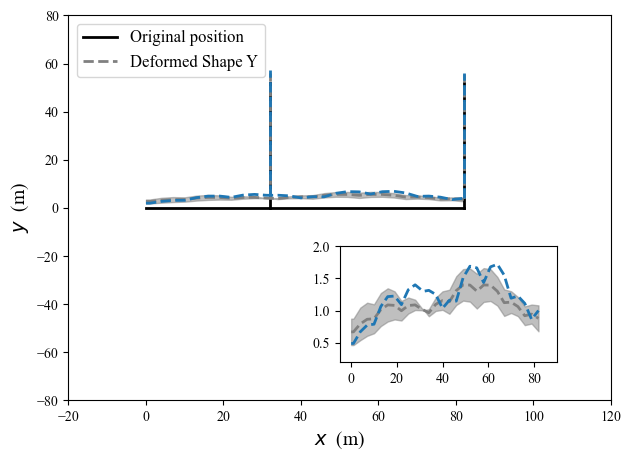

In [54]:
fig, ax = plt.subplots(ncols=1,figsize=(7,5))
ax.plot(x0m,y0m, color='k',lw=2,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=2)
ax.plot(x0b2,y0b2, color='k',lw=2)

ampx = 4
ax.plot(x0m,y0m+ampx*DSYML, color='grey',lw=2, ls='--',label='Deformed Shape Y')
ax.plot(x0b1,y0b1+ampx*DSYBL1, color='grey',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampx*DSYBL2, color='grey',lw=2, ls='--')

ax.plot(x0m,y0m+ampx*dsdy, color='C0',lw=2, ls='--')
ax.plot(x0b1,y0b1+ampx*dsdy[-1]*np.ones(len(y0b1)), color='C0',lw=2, ls='--')
ax.plot(x0b2,y0b2+ampx*dsdy[12]*np.ones(len(y0b2)), color='C0',lw=2, ls='--')
ax.fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.5)

axins1 = ax.inset_axes([0.5, 0.1, 0.4, 0.3],xlim=(-5,90), ylim=(0.2, 2))
axins1.plot(x0m,y0m+DSYML, color='grey',lw=2, ls='--')
axins1.plot(x0m,y0m+dsdy, color='C0',lw=2, ls='--')
axins1.fill_between(x0m,y0m+(DSYML+2*DSYMLs),y0m+(DSYML-2*DSYMLs),color='grey',alpha=0.5)

ax.set_xlim(-20, 120)
ax.set_ylim(-80,80)
ax.set_ylabel(r'$y$  (m)',fontsize=14)
ax.set_xlabel(r'$x$  (m)',fontsize=14)

plt.legend(fontsize=12)

In [55]:
Gy_NLTH, my_NLTH = Gamma(DSYm[:,5])
Gy_NLTH

0.9531392418440763

In [56]:
modal_my_NLTH = my_NLTH/np.sum(m)

In [57]:
my_NLTH

22.084042320558847

In [58]:
Gy_static = POy[10,1]
Gy_static

0.816

In [59]:
my_static = POy[10,2]
my_static

22.292

In [60]:
modal_my_static = POy[10,4]
modal_my_static*np.sum(m)

21.734910000000003

In [61]:
abs(Gy_static-Gy_NLTH)/Gy_NLTH

0.1438816448043285

In [62]:
abs(modal_my_NLTH-modal_my_static)/my_NLTH

0.000700454492766882

In [63]:
Dstaticy[10,:]

array([0.487, 0.669, 0.773, 0.787, 1.064, 1.217, 1.226, 1.092, 1.324,
       1.401, 1.313, 1.302, 1.315, 1.251, 1.035, 1.161, 1.147, 1.511,
       1.691, 1.665, 1.436, 1.681, 1.721, 1.551, 1.192, 1.226, 1.112,
       0.862, 1.   ])

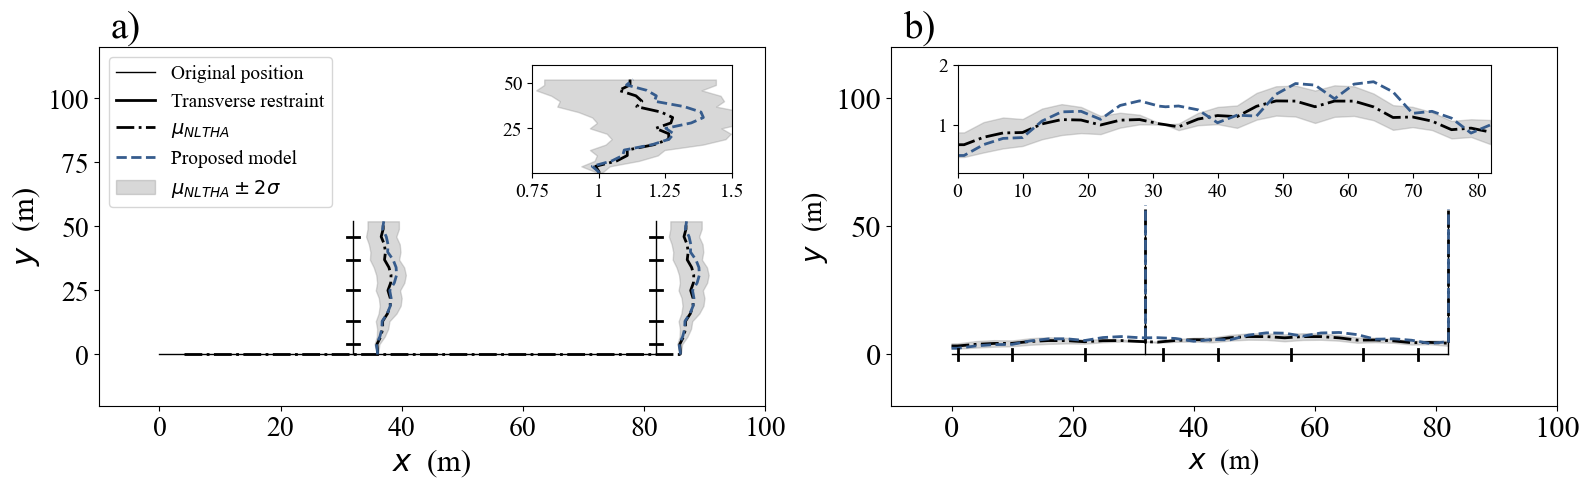

In [64]:
fig, ax = plt.subplots(ncols=2,figsize=(16,5))

ax[0].plot(x0m,y0m, color='k',lw=1,label='Original position')

ax[0].plot(x0b1,y0b1, color='k',lw=1)
ax[0].plot(x0b2,y0b2, color='k',lw=1)

ax[0].plot((31,33),(4,4),color='k',lw=2,label='Transverse restraint')
ax[0].plot((31,33),(13,13),color='k',lw=2)
ax[0].plot((31,33),(25,25),color='k',lw=2)
ax[0].plot((31,33),(37,37),color='k',lw=2)
ax[0].plot((31,33),(46,46),color='k',lw=2)

ax[0].plot((81,83),(4,4),color='k',lw=2)
ax[0].plot((81,83),(13,13),color='k',lw=2)
ax[0].plot((81,83),(25,25),color='k',lw=2)
ax[0].plot((81,83),(37,37),color='k',lw=2)
ax[0].plot((81,83),(46,46),color='k',lw=2)

ampx = 4
ax[0].plot(x0m+ampx*DSXML,y0m, color='k',lw=2, ls='-.',label=r'$\mu_{NLTHA}$')
ax[0].plot(x0b1+ampx*DSXBL1,y0b1, color='k',lw=2, ls='-.')
ax[0].plot(x0b2+ampx*DSXBL2,y0b2, color='k',lw=2, ls='-.')

ax[0].plot(x0b1+ampx*np.append(Dstaticx[0],Dstaticx),y0b1, color='#365c8d',lw=2, ls='--',label='Proposed model')
ax[0].plot(x0b2+ampx*np.append(Dstaticx[0],Dstaticx),y0b2, color='#365c8d',lw=2, ls='--')
ax[0].fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.3,label=r'$\mu_{NLTHA} \pm 2\sigma$')
ax[0].fill_betweenx(y0b1,x0b1+ampx*(DSXBL2+2*DSXBL2s),x0b1+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.3)


axins1 = ax[0].inset_axes([0.65, 0.65, 0.3, 0.3],xlim=(82.5,84), ylim=(0.5, 60))
axins1.plot(x0b1+DSXBL1,y0b1, color='k',lw=2, ls='-.')
axins1.plot(x0b1+np.append(Dstaticx[0],Dstaticx),y0b1, color='#365c8d',lw=2, ls='--')
axins1.fill_betweenx(y0b1,x0b1+(DSXBL1+2*DSXBL1s),x0b1+(DSXBL1-2*DSXBL1s),color='grey',alpha=0.3)
axins1.set_xticks(ticks=[82.5,83,83.5,84],labels=[0.75,1,1.25,1.5])
axins1.tick_params(labelsize=14)

ax[0].set_xlim(-10, 100)
ax[0].set_ylim(-20,120)
ax[0].tick_params(labelsize=20)
ax[0].set_ylabel(r'$y$  (m)',fontsize=22)
ax[0].set_xlabel(r'$x$  (m)',fontsize=22)
ax[0].text(-8,124,'a)',fontsize=28)

ax[0].legend(fontsize=14,loc=2)

ax[1].plot(x0m,y0m, color='k',lw=1,label='Original position')

ax[1].plot(x0b1,y0b1, color='k',lw=1)
ax[1].plot(x0b2,y0b2, color='k',lw=1)

ampx = 5
ax[1].plot(x0m,y0m+ampx*DSYML, color='k',lw=2, ls='-.',label='Deformed Shape Y')
ax[1].plot(x0b1,y0b1+ampx*DSYBL1, color='k',lw=2, ls='-.')
ax[1].plot(x0b2,y0b2+ampx*DSYBL2, color='k',lw=2, ls='-.')

ax[1].plot(x0m,y0m+ampx*dsdy, color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b1,y0b1+ampx*dsdy[-1]*np.ones(len(y0b1)), color='#365c8d',lw=2, ls='--')
ax[1].plot(x0b2,y0b2+ampx*dsdy[12]*np.ones(len(y0b2)), color='#365c8d',lw=2, ls='--')
ax[1].fill_between(x0m,y0m+ampx*(DSYML+2*DSYMLs),y0m+ampx*(DSYML-2*DSYMLs),color='grey',alpha=0.3)

ax[1].plot((1,1),(-2,2),color='k',lw=2)
ax[1].plot((10,10),(-2,2),color='k',lw=2)
ax[1].plot((22,22),(-2,2),color='k',lw=2)
ax[1].plot((35,35),(-2,2),color='k',lw=2)
ax[1].plot((44,44),(-2,2),color='k',lw=2)
ax[1].plot((56,56),(-2,2),color='k',lw=2)
ax[1].plot((68,68),(-2,2),color='k',lw=2)
ax[1].plot((77,77),(-2,2),color='k',lw=2)

axins1 = ax[1].inset_axes([0.1, 0.65, 0.8, 0.3],xlim=(0,82), ylim=(0.2, 2))
axins1.plot(x0m,y0m+DSYML, color='k',lw=2, ls='-.')
axins1.plot(x0m,y0m+dsdy, color='#365c8d',lw=2, ls='--')
axins1.fill_between(x0m,y0m+(DSYML+2*DSYMLs),y0m+(DSYML-2*DSYMLs),color='grey',alpha=0.3)
axins1.tick_params(labelsize=14)

ax[1].set_xlim(-10, 100)
ax[1].set_ylim(-20,120)
ax[1].tick_params(labelsize=22)
ax[1].set_ylabel(r'$y$  (m)',fontsize=20)
ax[1].set_xlabel(r'$x$  (m)',fontsize=20)
ax[1].text(-8,124,'b)',fontsize=28)
plt.tight_layout()

plt.savefig('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/Paper/Figure11.tiff',dpi=300)

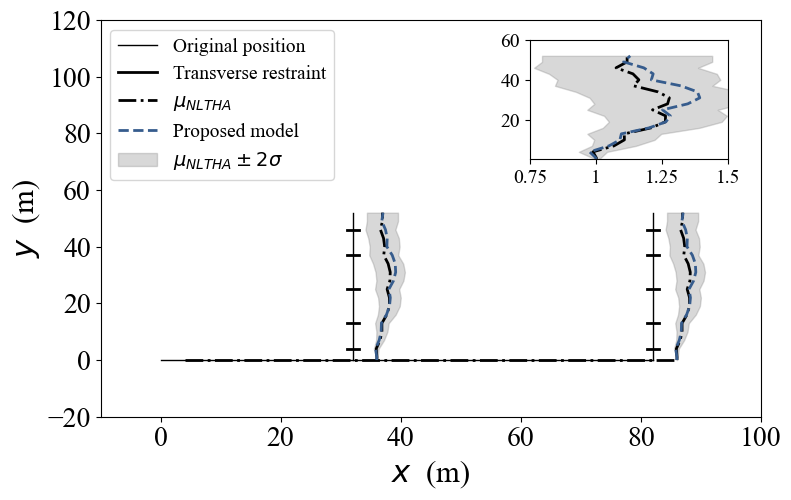

In [63]:
fig, ax = plt.subplots(ncols=1,figsize=(8,5))

ax.plot(x0m,y0m, color='k',lw=1,label='Original position')

ax.plot(x0b1,y0b1, color='k',lw=1)
ax.plot(x0b2,y0b2, color='k',lw=1)

ax.plot((31,33),(4,4),color='k',lw=2,label='Transverse restraint')
ax.plot((31,33),(13,13),color='k',lw=2)
ax.plot((31,33),(25,25),color='k',lw=2)
ax.plot((31,33),(37,37),color='k',lw=2)
ax.plot((31,33),(46,46),color='k',lw=2)

ax.plot((81,83),(4,4),color='k',lw=2)
ax.plot((81,83),(13,13),color='k',lw=2)
ax.plot((81,83),(25,25),color='k',lw=2)
ax.plot((81,83),(37,37),color='k',lw=2)
ax.plot((81,83),(46,46),color='k',lw=2)

ampx = 4
ax.plot(x0m+ampx*DSXML,y0m, color='k',lw=2, ls='-.',label=r'$\mu_{NLTHA}$')
ax.plot(x0b1+ampx*DSXBL1,y0b1, color='k',lw=2, ls='-.')
ax.plot(x0b2+ampx*DSXBL2,y0b2, color='k',lw=2, ls='-.')

ax.plot(x0b1+ampx*np.append(Dstaticx[0],Dstaticx),y0b1, color='#365c8d',lw=2, ls='--',label='Proposed model')
ax.plot(x0b2+ampx*np.append(Dstaticx[0],Dstaticx),y0b2, color='#365c8d',lw=2, ls='--')
ax.fill_betweenx(y0b2,x0b2+ampx*(DSXBL2+2*DSXBL2s),x0b2+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.3,label=r'$\mu_{NLTHA} \pm 2\sigma$')
ax.fill_betweenx(y0b1,x0b1+ampx*(DSXBL2+2*DSXBL2s),x0b1+ampx*(DSXBL2-2*DSXBL2s),color='grey',alpha=0.3)


axins1 = ax.inset_axes([0.65, 0.65, 0.3, 0.3],xlim=(82.5,84), ylim=(0.5, 60))
axins1.plot(x0b1+DSXBL1,y0b1, color='k',lw=2, ls='-.')
axins1.plot(x0b1+np.append(Dstaticx[0],Dstaticx),y0b1, color='#365c8d',lw=2, ls='--')
axins1.fill_betweenx(y0b1,x0b1+(DSXBL1+2*DSXBL1s),x0b1+(DSXBL1-2*DSXBL1s),color='grey',alpha=0.3)
axins1.set_xticks(ticks=[82.5,83,83.5,84],labels=[0.75,1,1.25,1.5])
axins1.tick_params(labelsize=14)

ax.set_xlim(-10, 100)
ax.set_ylim(-20,120)
ax.tick_params(labelsize=20)
ax.set_ylabel(r'$y$  (m)',fontsize=22)
ax.set_xlabel(r'$x$  (m)',fontsize=22)
#ax.text(-8,124,'a)',fontsize=28)

ax.legend(fontsize=14,loc=2)
plt.tight_layout()
plt.savefig('C:/Users/rmeri/Documents/UCL/SuspendedNSEs/RIAGE 2026/Figure4.tiff',dpi=300)